# 06 — Covariance Analysis

This notebook documents the preparation and inspection of the Gaussian covariance
matrix computed by [OneCovariance](https://github.com/rreischke/OneCovariance).

The covariance matrix $C_{ij} = \langle \delta w(\theta_i)\, \delta w(\theta_j) \rangle$
is needed for:
- Correct $\chi^2$ goodness-of-fit of theoretical models.
- Comparison between samples accounting for correlated bins.

**Inputs generated by** `scripts/run_covariance.py`:
- `n(z)` ASCII file (redshift distribution)
- Bias file $b(z) = {\rm const}$
- Pair-count file (DD per bin)
- HEALPix nside=1024 mask
- `config.ini` for OneCovariance

In [5]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from src.config import cfg, resolve_path
from src.correlation import CorrelationResult

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

SAMPLE = "edf_s_irac_footprint"

## 1. Inspect OneCovariance input files

In [6]:
cov_dir = resolve_path(cfg["paths"]["cov_dir"]) / SAMPLE
print(f"OneCovariance input directory: {cov_dir}")

if cov_dir.exists():
    for p in sorted(cov_dir.rglob("*")):
        if p.is_file():
            size_kb = p.stat().st_size / 1024
            print(f"  {p.relative_to(cov_dir)}  ({size_kb:.1f} KB)")
else:
    print(f"  Directory not found. Run first:")
    print(f"    python scripts/run_covariance.py --sample {SAMPLE}")

OneCovariance input directory: /home/k3vinpaul/LRDs/results/covariance_matrices/edf_s_irac_footprint
  config.ini  (2.0 KB)
  input/bias/bias.ascii  (0.7 KB)
  input/mask/mask_healpix_nside1024.fits  (49159.7 KB)
  input/npair/npair_gg_Bin1_Bin1.ascii  (0.8 KB)
  input/redshift_distribution/nz_bin1.ascii  (0.9 KB)
  output/corrcoeff.pdf  (17.4 KB)
  output/cov_list.dat  (18.4 KB)
  output/cov_matrix.mat  (3.4 KB)
  output/save_configs.ini  (3.0 KB)


## 2. Redshift distribution used

In [7]:
nz_path = cov_dir / "nz.txt"
if nz_path.exists():
    nz_data = np.loadtxt(str(nz_path))
    z_mid   = (nz_data[:, 0] + nz_data[:, 1]) / 2.0
    nz      = nz_data[:, 2]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(z_mid, nz, width=(z_mid[1] - z_mid[0]) * 0.9,
           color="steelblue", alpha=0.7, label="n(z) input")
    ax.set_xlabel("Redshift z")
    ax.set_ylabel("n(z) [normalised]")
    ax.set_title(f"Redshift distribution — {SAMPLE}")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f"n(z) file not found: {nz_path}")

n(z) file not found: /home/k3vinpaul/LRDs/results/covariance_matrices/edf_s_irac_footprint/nz.txt


## 3. Load the covariance matrix

OneCovariance writes the covariance matrix to a file in `output/`. The exact
filename depends on the configuration. Adjust `cov_file` below as needed.

In [8]:
output_dir = cov_dir / "output"

if output_dir.exists():
    output_files = sorted(output_dir.iterdir())
    print("OneCovariance output files:")
    for f in output_files:
        print(f"  {f.name}  ({f.stat().st_size/1024:.1f} KB)")

    # Load cov_matrix.mat (space-separated floats) or cov_list.dat (tabular with headers)
    mat_file  = output_dir / "cov_matrix.mat"
    list_file = output_dir / "cov_list.dat"
    if mat_file.exists():
        cov_file = mat_file
        print(f"\nLoading: {cov_file.name}")
        cov = np.loadtxt(str(cov_file))
        print(f"  Shape: {cov.shape}")
    elif list_file.exists():
        cov_file = list_file
        print(f"\nLoading: {cov_file.name}")
        # cov_list.dat has string columns — extract numeric cov column (index 10)
        data = np.genfromtxt(str(cov_file), comments="#", dtype=None, encoding=None)
        n = int(np.sqrt(len(data)))
        cov = np.array([row[10] for row in data], dtype=float).reshape(n, n)
        print(f"  Shape: {cov.shape}")
    else:
        print("\nNo covariance matrix file found in output/ yet.")
        cov = None
else:
    print(f"Output directory not found: {output_dir}")
    print("Run OneCovariance first:\n  python scripts/run_covariance.py --sample "
          f"{SAMPLE} --run")
    cov = None

OneCovariance output files:
  corrcoeff.pdf  (17.4 KB)
  cov_list.dat  (18.4 KB)
  cov_matrix.mat  (3.4 KB)
  save_configs.ini  (3.0 KB)

Loading: cov_matrix.mat
  Shape: (15, 15)


## 4. Visualise the covariance and correlation matrices

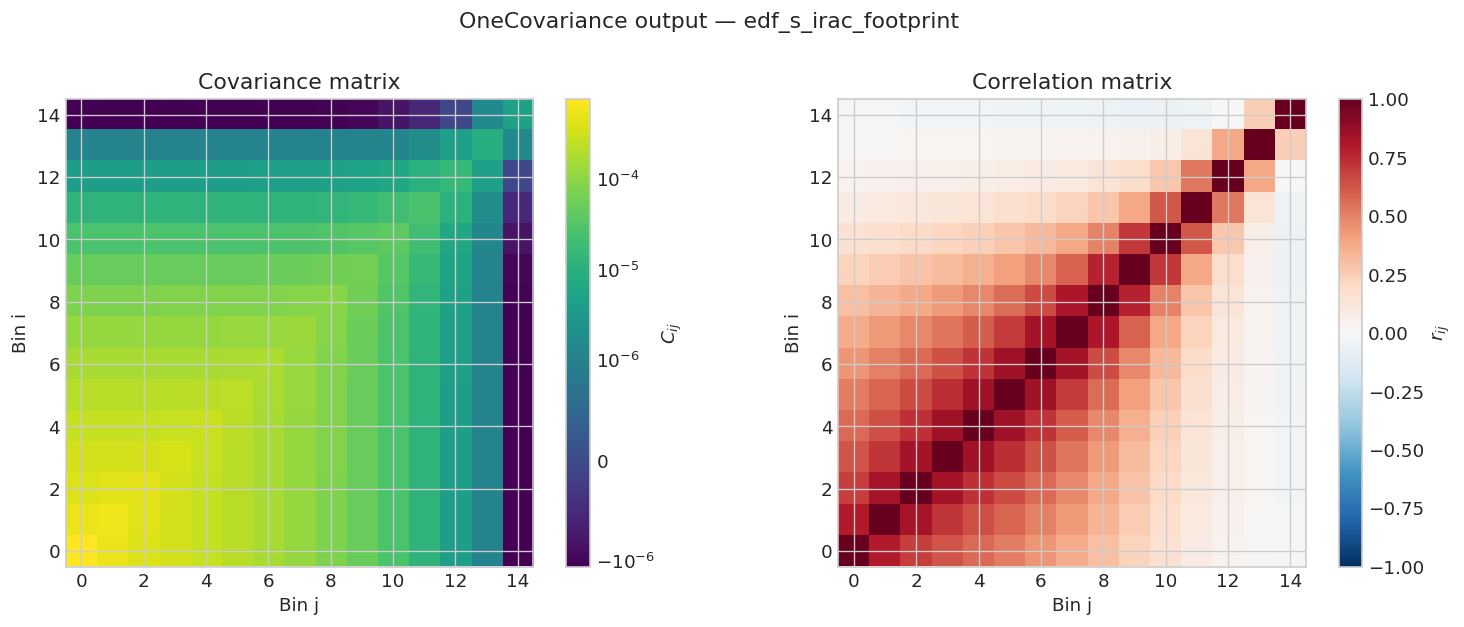


Diagonal (marginal) errors from covariance:
  Bin  0  σ_cov = 0.02769
  Bin  1  σ_cov = 0.02440
  Bin  2  σ_cov = 0.02173
  Bin  3  σ_cov = 0.01938
  Bin  4  σ_cov = 0.01722
  Bin  5  σ_cov = 0.01517
  Bin  6  σ_cov = 0.01321
  Bin  7  σ_cov = 0.01131
  Bin  8  σ_cov = 0.00950
  Bin  9  σ_cov = 0.00782
  Bin 10  σ_cov = 0.00630
  Bin 11  σ_cov = 0.00500
  Bin 12  σ_cov = 0.00386
  Bin 13  σ_cov = 0.00291
  Bin 14  σ_cov = 0.00218


In [9]:
if cov is not None and cov.ndim == 2 and cov.shape[0] == cov.shape[1]:
    n = cov.shape[0]
    # Correlation matrix
    diag  = np.sqrt(np.diag(cov))
    corr  = cov / np.outer(diag, diag)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    im0 = axes[0].imshow(cov, origin="lower", cmap="viridis",
                          norm=mcolors.SymLogNorm(linthresh=1e-6,
                                                  vmin=cov.min(), vmax=cov.max()))
    plt.colorbar(im0, ax=axes[0], label=r"$C_{ij}$")
    axes[0].set_title("Covariance matrix")
    axes[0].set_xlabel("Bin j")
    axes[0].set_ylabel("Bin i")

    im1 = axes[1].imshow(corr, origin="lower", cmap="RdBu_r", vmin=-1, vmax=1)
    plt.colorbar(im1, ax=axes[1], label=r"$r_{ij}$")
    axes[1].set_title("Correlation matrix")
    axes[1].set_xlabel("Bin j")
    axes[1].set_ylabel("Bin i")

    plt.suptitle(f"OneCovariance output — {SAMPLE}", y=1.02)
    plt.tight_layout()
    plt.show()

    print("\nDiagonal (marginal) errors from covariance:")
    for i, s in enumerate(diag):
        print(f"  Bin {i:2d}  σ_cov = {s:.5f}")
else:
    print("(Covariance matrix not yet available — run OneCovariance first)")

## 5. Compare marginal covariance errors with Poisson + simulation

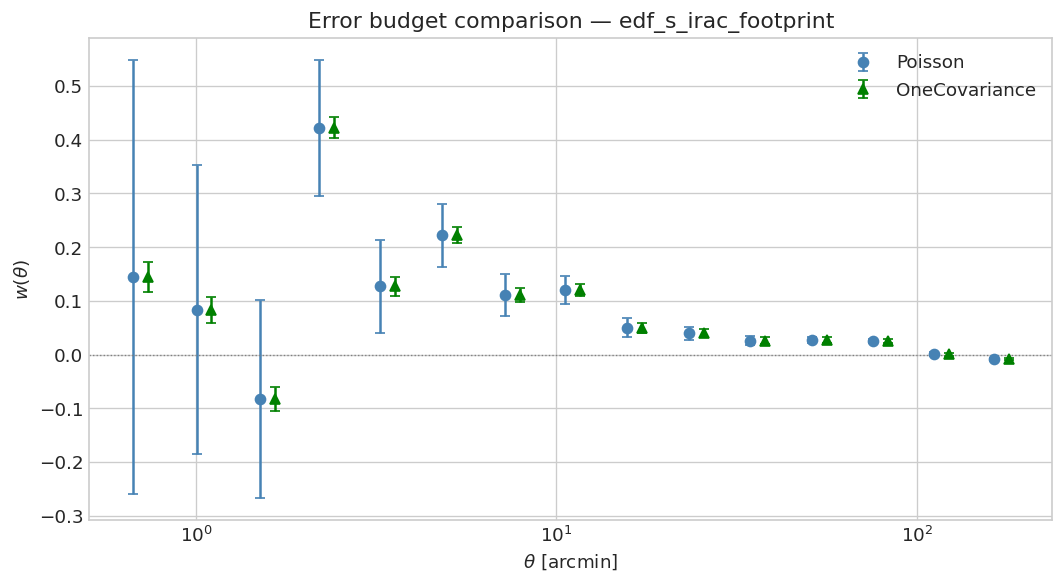

In [10]:
corr_path = resolve_path(cfg["paths"]["corr_dir"]) / f"2pacf_{SAMPLE}.npz"
sim_path  = resolve_path(cfg["paths"]["cov_dir"]) / f"sim_errors_{SAMPLE}.npz"

if corr_path.exists() and cov is not None:
    from src.errors import compute_poisson_errors
    result  = CorrelationResult.load(str(corr_path))
    poisson = compute_poisson_errors(result)
    sigma_cov = np.sqrt(np.diag(cov)) if cov.shape[0] == len(result.theta_arcmin) else None

    fig, ax = plt.subplots(figsize=(9, 5))
    theta = result.theta_arcmin
    ax.errorbar(theta, result.w, yerr=poisson, fmt="o", capsize=3,
                label="Poisson", color="steelblue")

    if sim_path.exists():
        sim_data = np.load(str(sim_path))
        ax.errorbar(theta * 1.05, result.w, yerr=sim_data["std_w"],
                    fmt="s", capsize=3, label="Simulation", color="darkorange")

    if sigma_cov is not None:
        ax.errorbar(theta * 1.10, result.w, yerr=sigma_cov,
                    fmt="^", capsize=3, label="OneCovariance", color="green")

    ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
    ax.set_xscale("log")
    ax.set_xlabel(r"$\theta$ [arcmin]")
    ax.set_ylabel(r"$w(\theta)$")
    ax.set_title(f"Error budget comparison — {SAMPLE}")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("(Cannot make comparison plot — need both corr result and covariance matrix)")

## Summary

The Gaussian covariance matrix from OneCovariance accounts for:
- Shot noise (diagonal)
- Cosmic variance (off-diagonal mode coupling)
- Survey geometry (mask power spectrum)
- Galaxy bias $b(z) = {\rm const}$

Comparing the three error estimates reveals which uncertainty source dominates
at each angular scale.

Proceed to **07_final_comparison** for the science-grade multi-sample comparison.